In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path

In [5]:

# Global plotting style
plt.rcParams.update({
    "text.usetex": False,  # Set True if LaTeX installed
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

In [6]:
results = json.load(Path("results_combined.json").open())
results

[{'name': 'DQN Standard',
  'variant': 'standard',
  'category': 'agent',
  'final_train_win_rate': 0.4,
  'final_train_reward': -1.5777160835021349,
  'eval_win_rate_weak': 0.42,
  'eval_reward_weak': -0.06884259595297543,
  'eval_win_rate_strong': 0.36,
  'eval_reward_strong': -3.06345540762052,
  'best_eval_win_rate': 0.58,
  'log_dir': 'logs/ablation/DQN_standard_20260217_213744'},
 {'name': 'Double DQN',
  'variant': 'double',
  'category': 'agent',
  'final_train_win_rate': 0.41,
  'final_train_reward': -0.27335121340059976,
  'eval_win_rate_weak': 0.48,
  'eval_reward_weak': 0.22567272904695979,
  'eval_win_rate_strong': 0.32,
  'eval_reward_strong': -3.4737342433041865,
  'best_eval_win_rate': 0.56,
  'log_dir': 'logs/ablation/DDQN_20260217_220214'},
 {'name': 'Dueling DQN',
  'variant': 'dueling',
  'category': 'agent',
  'final_train_win_rate': 0.44,
  'final_train_reward': -0.20954966891367338,
  'eval_win_rate_weak': 0.46,
  'eval_reward_weak': 0.3393260370635099,
  'eval_w

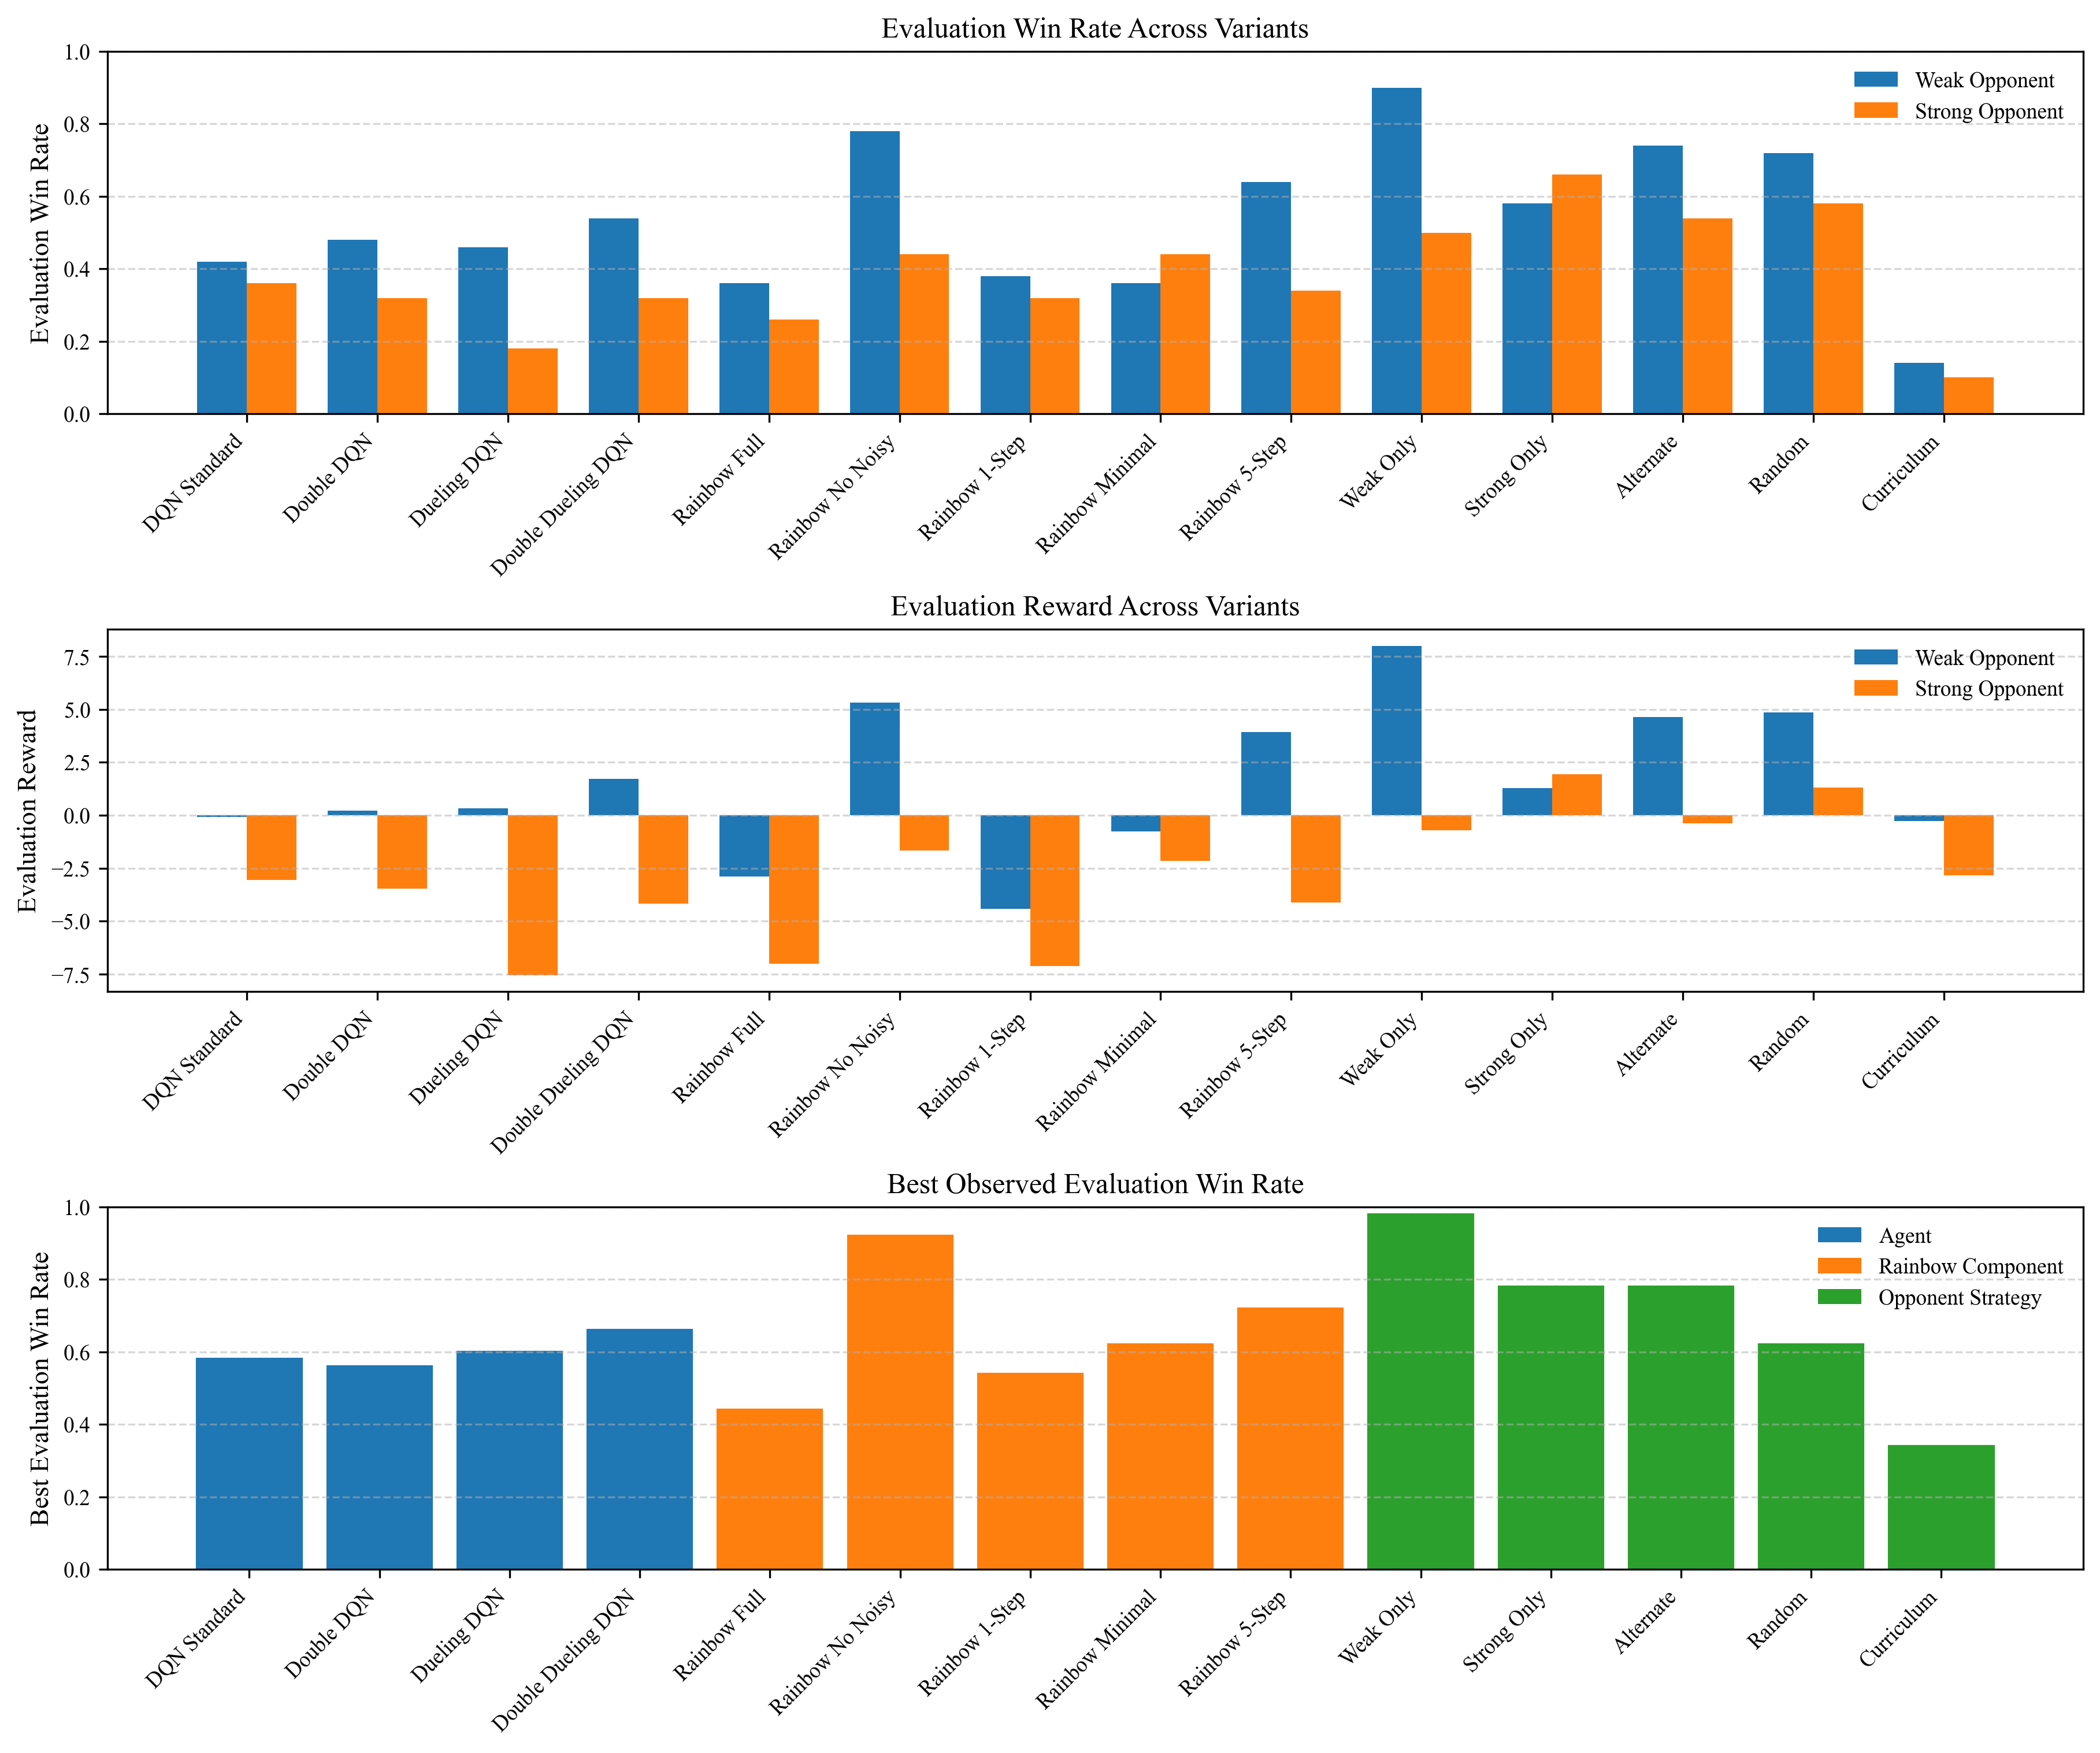

In [7]:


# =========================
# Prepare data
# =========================
names = [r["name"] for r in results]
weak_win = [r["eval_win_rate_weak"] for r in results]
strong_win = [r["eval_win_rate_strong"] for r in results]
weak_reward = [r["eval_reward_weak"] for r in results]
strong_reward = [r["eval_reward_strong"] for r in results]
best_win = [r["best_eval_win_rate"] for r in results]
categories = [r["category"] for r in results]

x = np.arange(len(names))
width = 0.38

# Category-based color grouping
category_colors = {
    "agent": "#1f77b4",
    "rainbow_component": "#ff7f0e",
    "opponent_strategy": "#2ca02c",
}

bar_colors = [category_colors[c] for c in categories]

# =========================
# Create figure
# =========================
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

# -------------------------
# 1. Win Rate
# -------------------------
ax = axes[0]
ax.bar(x - width/2, weak_win, width, label="Weak Opponent")
ax.bar(x + width/2, strong_win, width, label="Strong Opponent")

ax.set_ylabel("Evaluation Win Rate")
ax.set_title("Evaluation Win Rate Across Variants")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(frameon=False)

# -------------------------
# 2. Rewards
# -------------------------
ax = axes[1]
ax.bar(x - width/2, weak_reward, width, label="Weak Opponent")
ax.bar(x + width/2, strong_reward, width, label="Strong Opponent")

ax.set_ylabel("Evaluation Reward")
ax.set_title("Evaluation Reward Across Variants")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(frameon=False)

# -------------------------
# 3. Best Win Rate
# -------------------------
ax = axes[2]
bars = ax.bar(x, best_win)

# Color bars by category
for bar, color in zip(bars, bar_colors):
    bar.set_color(color)

ax.set_ylabel("Best Evaluation Win Rate")
ax.set_title("Best Observed Evaluation Win Rate")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Custom legend for categories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=cat.replace("_", " ").title())
    for cat, color in category_colors.items()
]
ax.legend(handles=legend_elements, frameon=False)

# =========================
# Save figure
# =========================
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

plt.savefig(output_dir / "ablation_results.pdf", bbox_inches="tight")
plt.savefig(output_dir / "ablation_results.png", bbox_inches="tight")

plt.show()

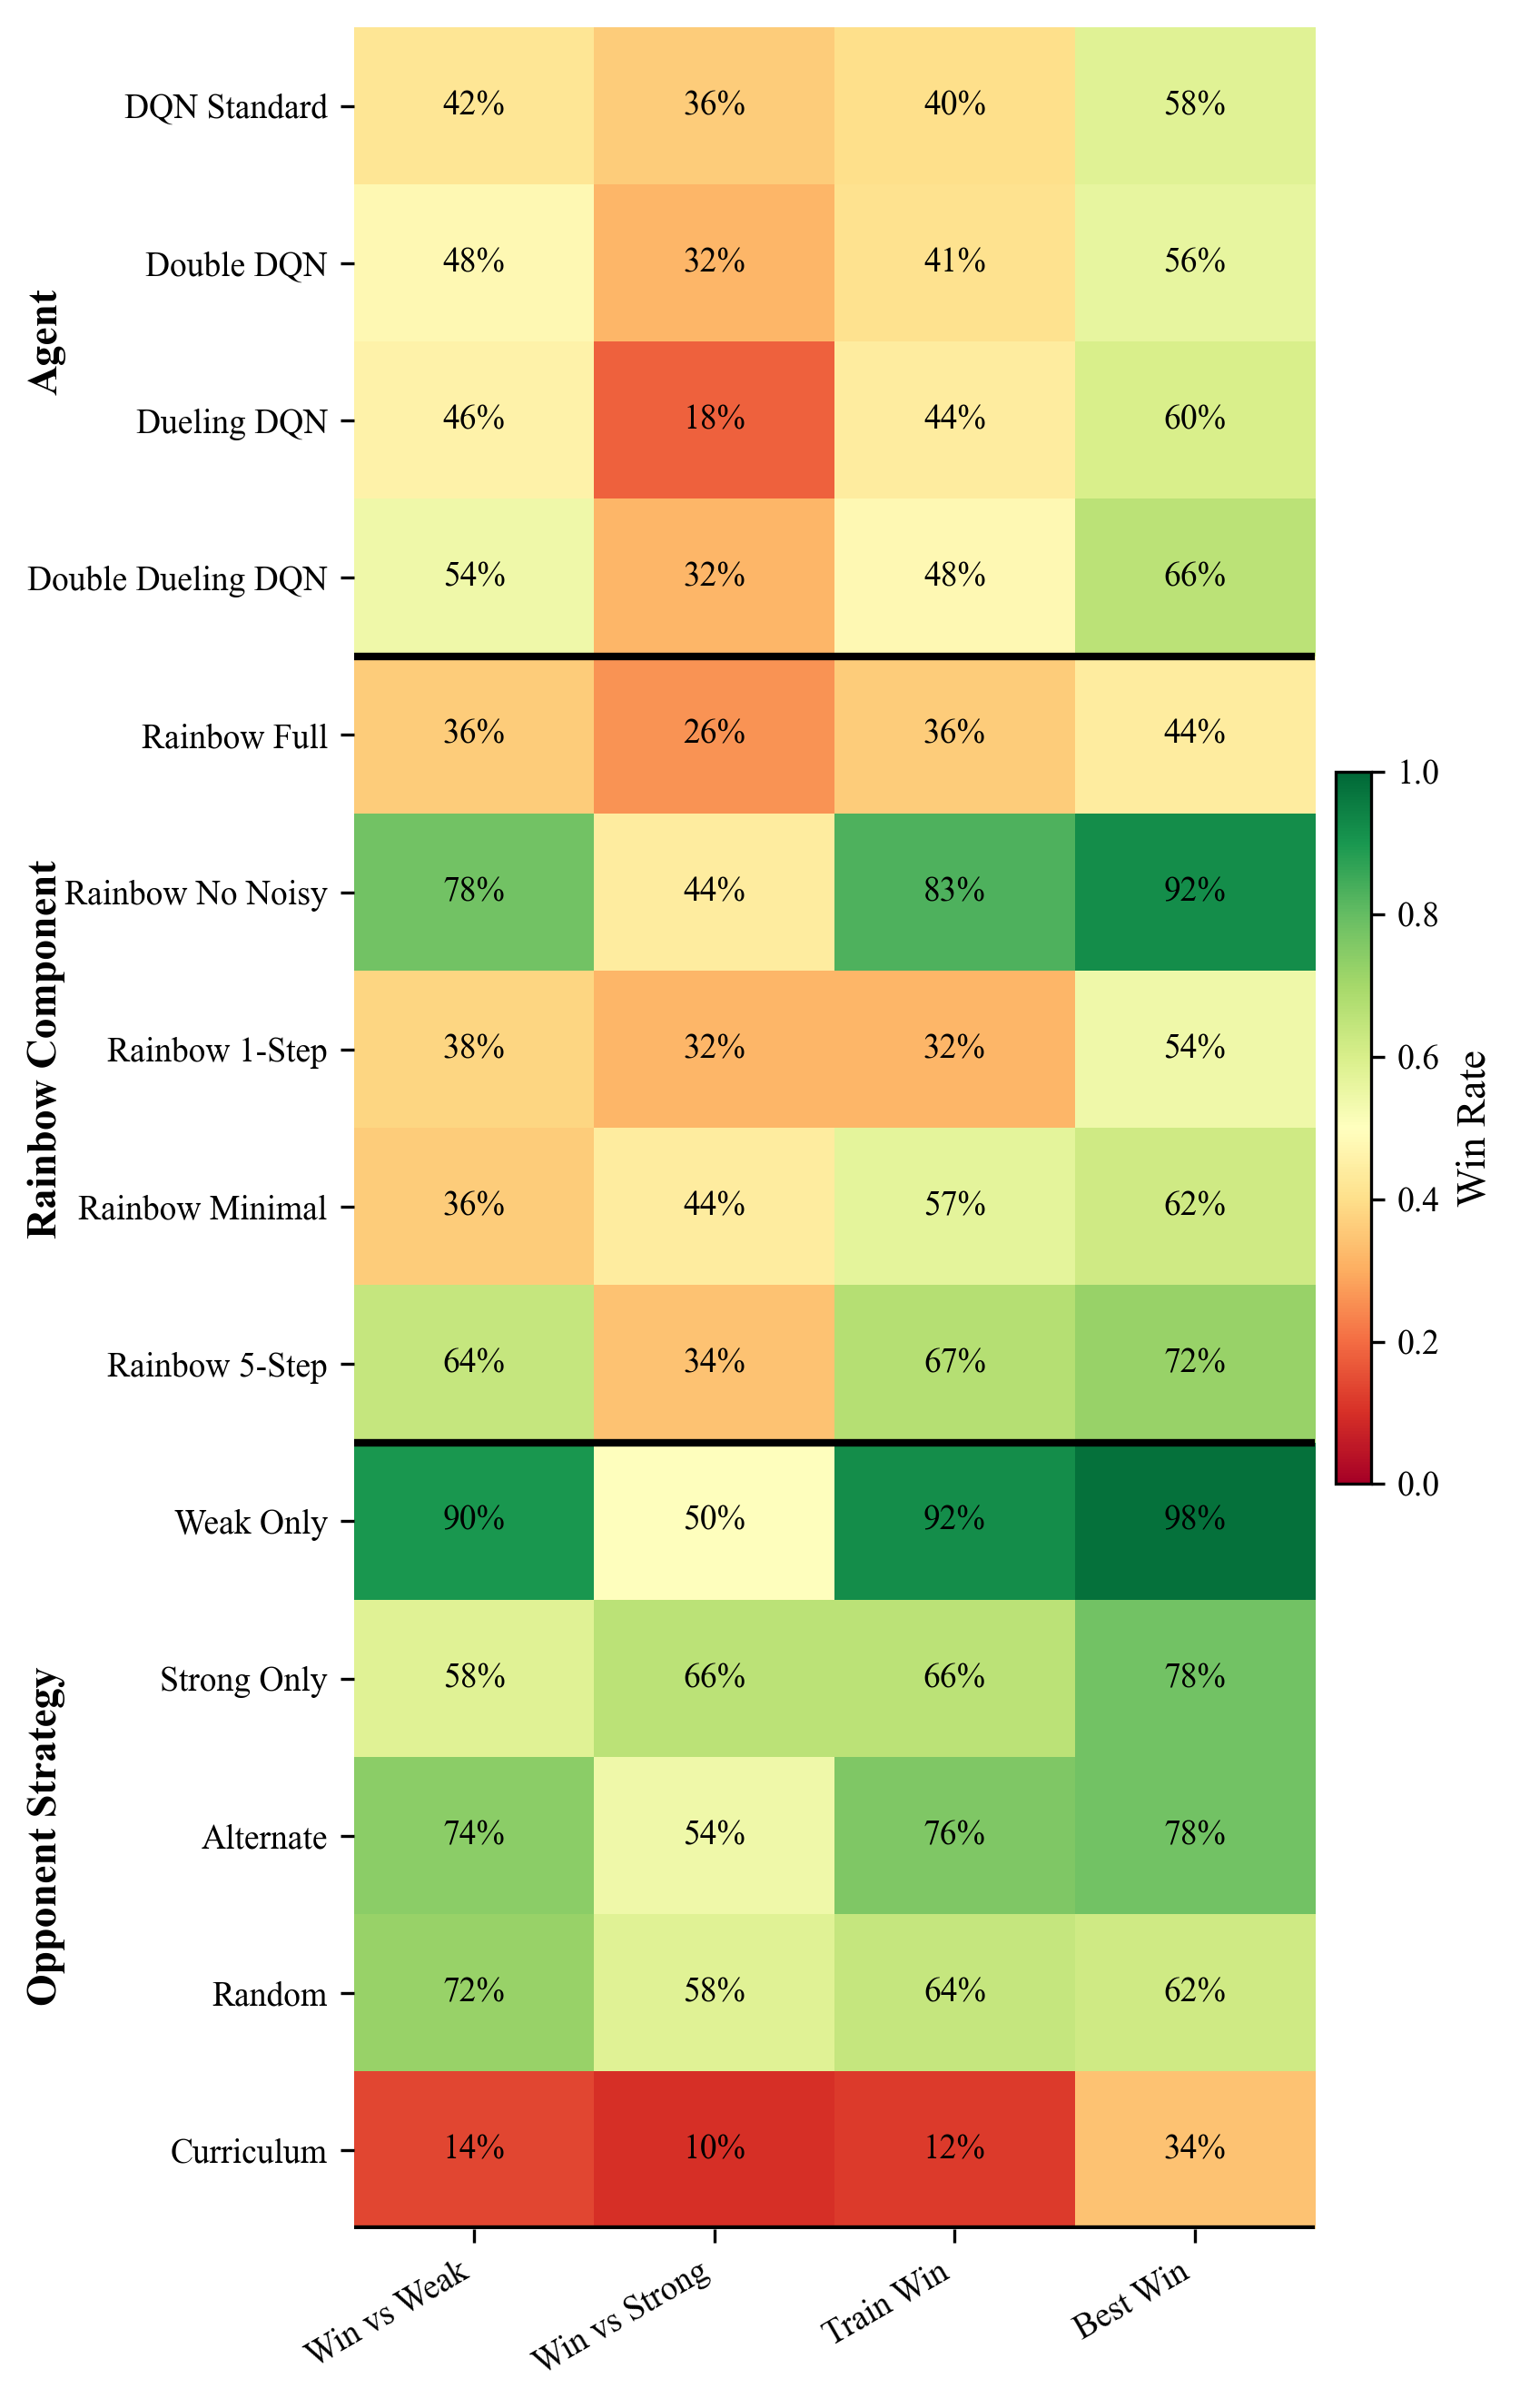

In [8]:

# -----------------------
# Extract win metrics only
# -----------------------
names = [r["name"] for r in results]
categories = [r["category"] for r in results]

metrics = [
    ("eval_win_rate_weak", "Win vs Weak"),
    ("eval_win_rate_strong", "Win vs Strong"),
    ("final_train_win_rate", "Train Win"),
    ("best_eval_win_rate", "Best Win"),
]

data = np.array([[r[m[0]] for m in metrics] for r in results])

# -----------------------
# Sort by category
# -----------------------
sorted_categories = ['agent', 'rainbow_component', 'opponent_strategy']
order = np.argsort([sorted_categories.index(c) for c in categories])
data = data[order]
names = [names[i] for i in order]
categories = [categories[i] for i in order]

# -----------------------
# Plot
# -----------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

fig, ax = plt.subplots(figsize=(6, 9))

im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

# Ticks
ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels([m[1] for m in metrics], rotation=30, ha="right")

ax.set_yticks(np.arange(len(names)))
ax.set_yticklabels(names)

# Annotate values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(
            j, i,
            f"{data[i, j]*100:.0f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

# -----------------------
# Category separation
# -----------------------
current_cat = categories[0]
start_idx = 0

for i, cat in enumerate(categories + ["END"]):
    if cat != current_cat:
        # Thick separator line
        ax.axhline(i - 0.5, color="black", linewidth=2)

        # Category label
        mid = (start_idx + i - 1) / 2
        ax.text(
            -1.7,
            mid,
            current_cat.replace("_", " ").title(),
            va="center",
            ha="right",
            fontsize=11,
            fontweight="bold",
            rotation=90
        )

        start_idx = i
        current_cat = cat

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Win Rate")

# ax.set_title("Ablation Study Results")

plt.tight_layout()

# Save
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / "ablation_heatmap_grouped.pdf", bbox_inches="tight")
plt.savefig(output_dir / "ablation_heatmap_grouped.png", bbox_inches="tight")

plt.show()

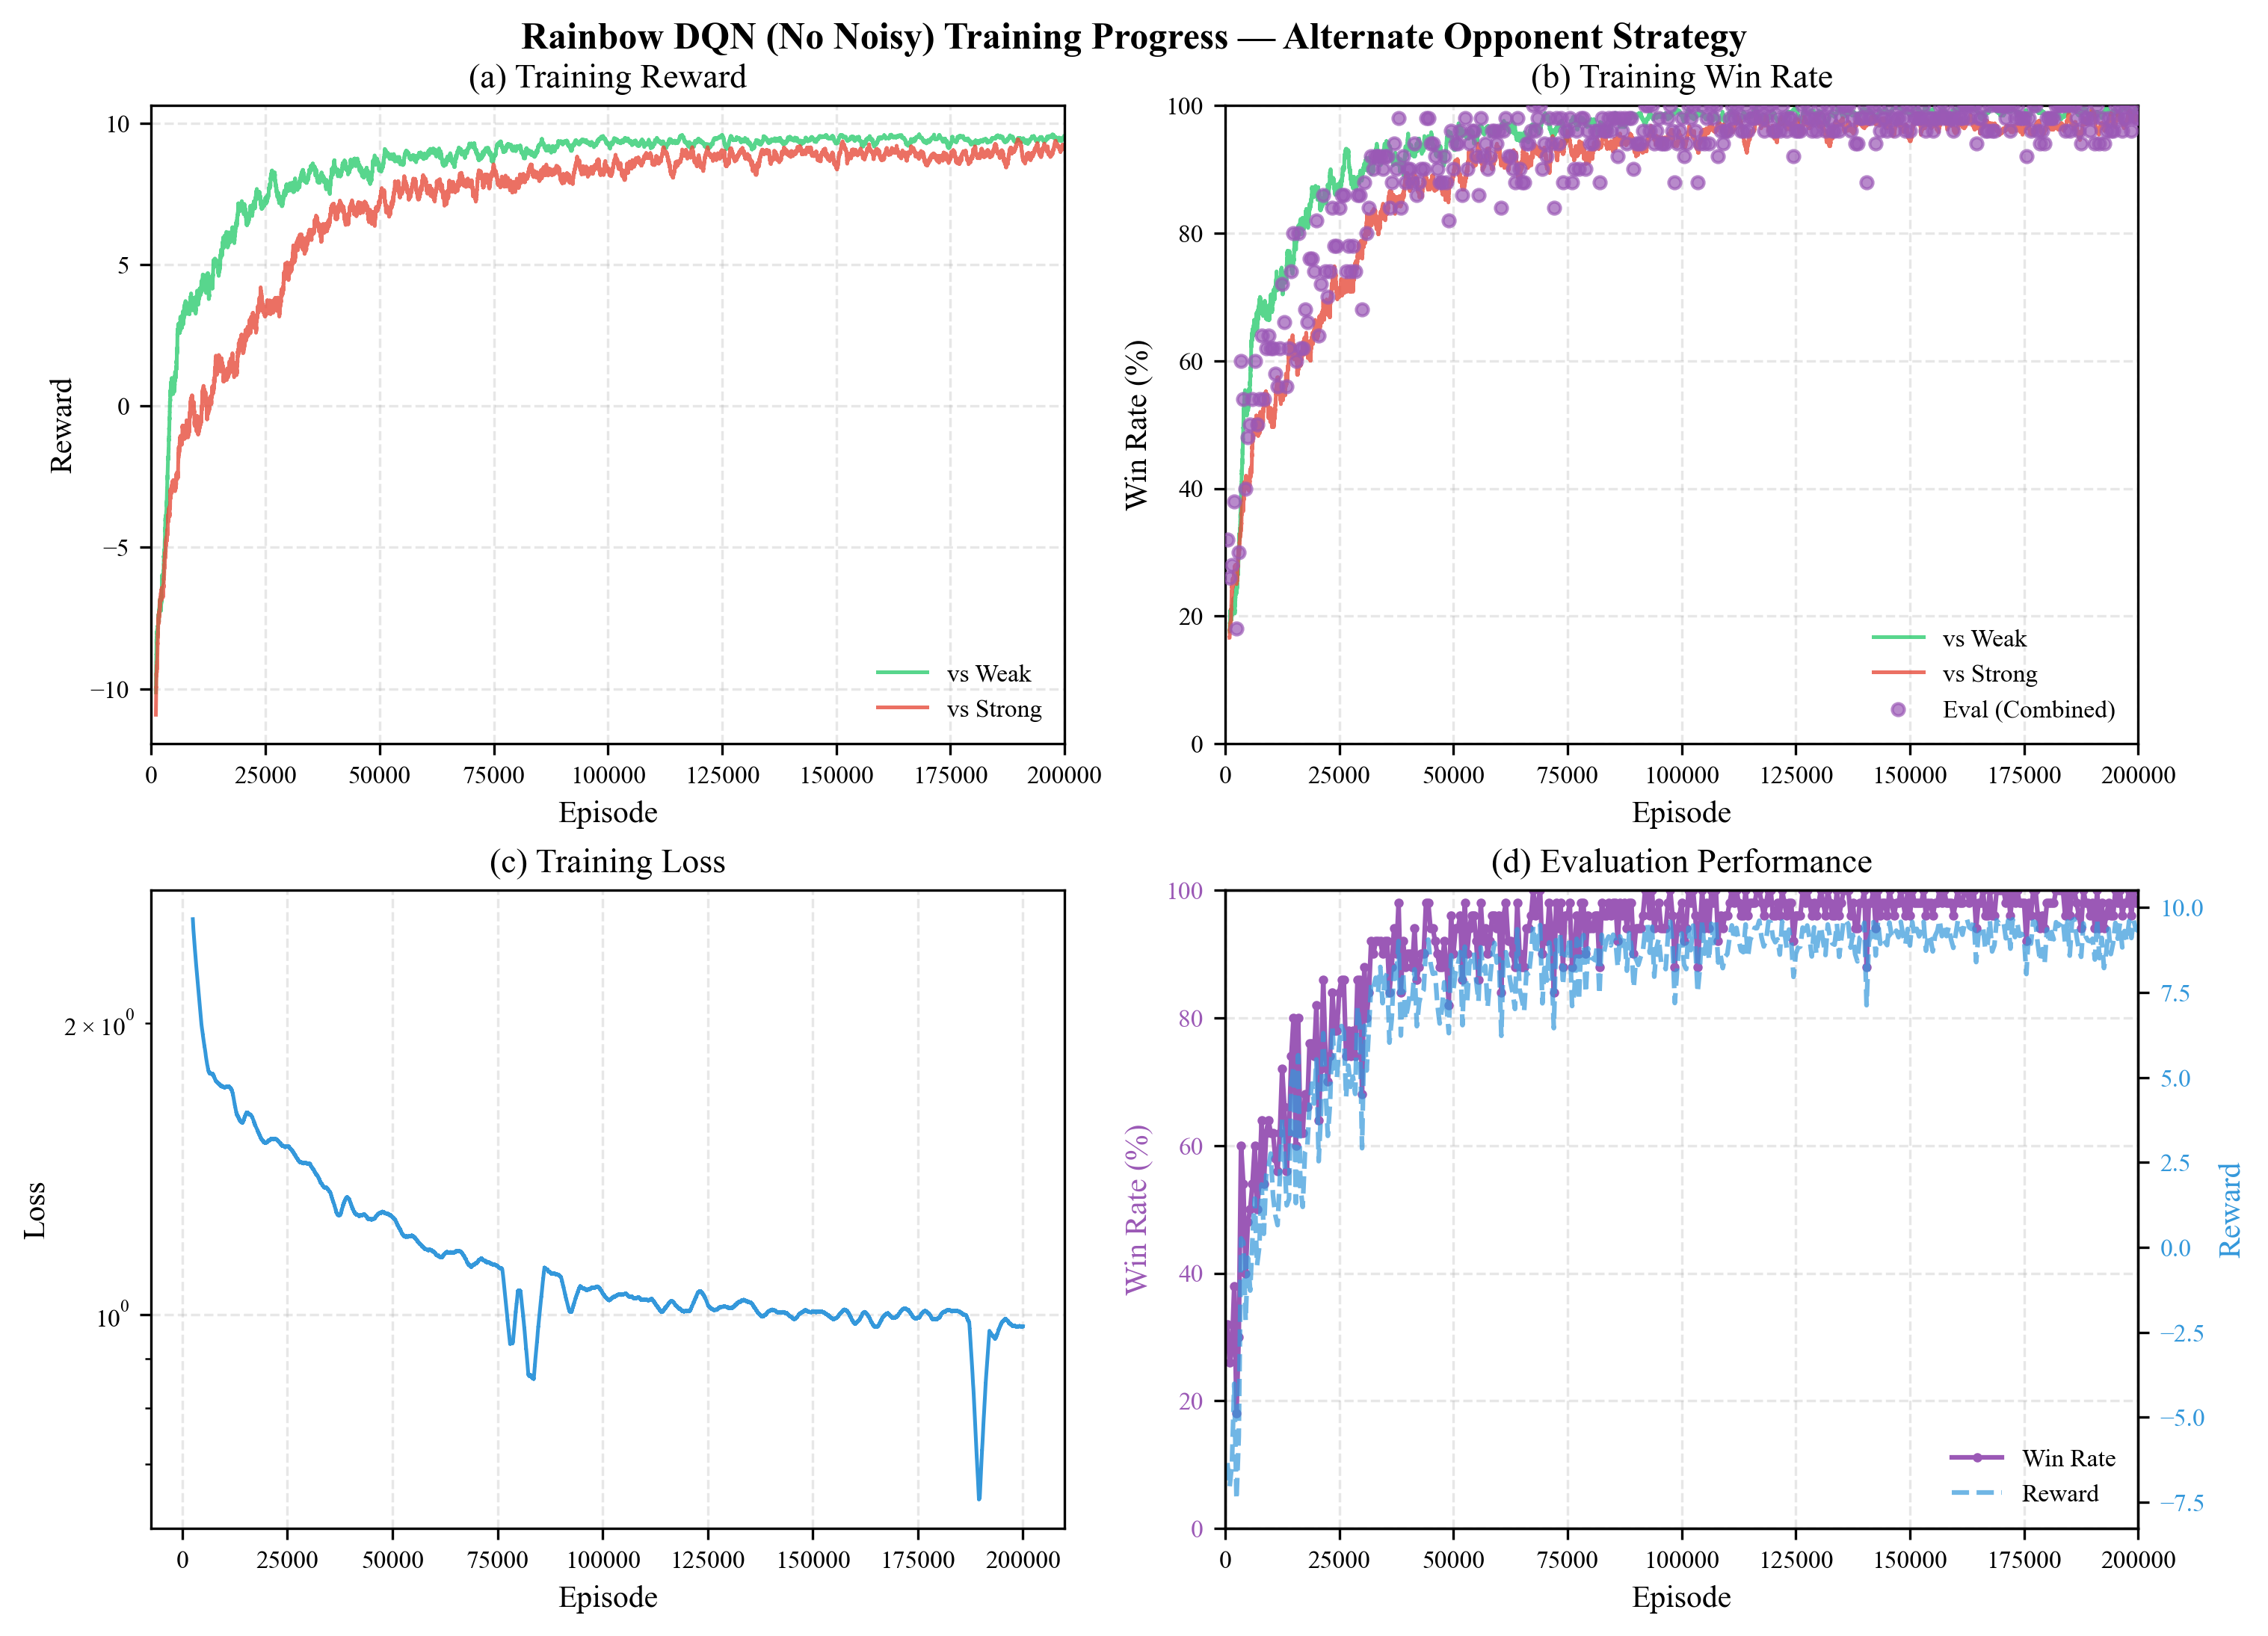

Figure saved to figures/training_progress_200k.pdf
Episodes plotted: 200000
Final smoothed win rate (weak): 99.8%
Final smoothed win rate (strong): 97.8%
Best eval win rate: 100.0%


In [9]:
# =========================
# Training Progress Plot for Rainbow No Noisy (Alternate Training)
# =========================

# Configuration: set k to limit the number of episodes to plot
k = 200000  # Plot only first k episodes (set to None for all)

# Load training data
log_dir = Path("logs/Rainbow_no_noisy_20260222_011934")

episode_rewards = np.load(log_dir / "episode_rewards.npy")
episode_wins = np.load(log_dir / "episode_wins.npy")
eval_rewards = np.load(log_dir / "eval_rewards.npy")
eval_win_rates = np.load(log_dir / "eval_win_rates.npy")
losses = np.load(log_dir / "losses.npy")

# Load config for eval frequency
with open(log_dir / "config.json") as f:
    config = json.load(f)

eval_freq = config.get("eval_frequency", 500)

# Limit data to first k episodes
if k is not None:
    episode_rewards = episode_rewards[:k]
    episode_wins = episode_wins[:k]
    n_evals = k // eval_freq
    eval_rewards = eval_rewards[:n_evals]
    eval_win_rates = eval_win_rates[:n_evals]
    losses = losses[:k]  

# Compute smoothed metrics
def smooth(data, window=1000):
    """Compute rolling mean with given window size."""
    if len(data) < window:
        window = max(1, len(data) // 10)
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

# Compute win rates from episode_wins (1=win, 0=draw, -1=loss)
win_binary = (episode_wins == 1).astype(float)

# Separate weak/strong performance (alternate training: odd=weak, even=strong)
episodes = np.arange(1, len(episode_rewards) + 1)
weak_mask = (episodes % 2 == 1)
strong_mask = (episodes % 2 == 0)

weak_rewards = episode_rewards[weak_mask]
strong_rewards = episode_rewards[strong_mask]
weak_wins = win_binary[weak_mask]
strong_wins = win_binary[strong_mask]

# Smooth window
window = 500

smoothed_reward = smooth(episode_rewards, window)
smoothed_win_rate = smooth(win_binary, window)
smoothed_weak_reward = smooth(weak_rewards, window)
smoothed_strong_reward = smooth(strong_rewards, window)
smoothed_weak_win = smooth(weak_wins, window)
smoothed_strong_win = smooth(strong_wins, window)
smoothed_loss = smooth(losses, window * 5) if len(losses) > window * 5 else losses

# Evaluation episodes
eval_episodes = np.arange(eval_freq, eval_freq * len(eval_rewards) + 1, eval_freq)

# =========================
# Create publication figure
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

# Color scheme
color_weak = "#2ecc71"
color_strong = "#e74c3c"
color_combined = "#3498db"
color_eval = "#9b59b6"

# -------------------------
# Panel A: Episode Rewards
# -------------------------
ax = axes[0, 0]

# Plot weak vs strong rewards
ep_weak = np.arange(window, len(smoothed_weak_reward) + window) * 2 - 1
ep_strong = np.arange(window, len(smoothed_strong_reward) + window) * 2

ax.plot(ep_weak, smoothed_weak_reward, color=color_weak, alpha=0.8, linewidth=1.2, label="vs Weak")
ax.plot(ep_strong, smoothed_strong_reward, color=color_strong, alpha=0.8, linewidth=1.2, label="vs Strong")

ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.set_title("(a) Training Reward")
ax.legend(frameon=False, loc="lower right")
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_xlim(0, k if k else len(episode_rewards))

# -------------------------
# Panel B: Win Rate
# -------------------------
ax = axes[0, 1]

ep_weak_win = np.arange(window, len(smoothed_weak_win) + window) * 2 - 1
ep_strong_win = np.arange(window, len(smoothed_strong_win) + window) * 2

ax.plot(ep_weak_win, smoothed_weak_win * 100, color=color_weak, alpha=0.8, linewidth=1.2, label="vs Weak")
ax.plot(ep_strong_win, smoothed_strong_win * 100, color=color_strong, alpha=0.8, linewidth=1.2, label="vs Strong")

# Add evaluation win rates
ax.scatter(eval_episodes, eval_win_rates * 100, color=color_eval, s=15, alpha=0.7, marker="o", label="Eval (Combined)", zorder=5)

ax.set_xlabel("Episode")
ax.set_ylabel("Win Rate (%)")
ax.set_title("(b) Training Win Rate")
ax.legend(frameon=False, loc="lower right")
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_ylim(0, 100)
ax.set_xlim(0, k if k else len(episode_rewards))

# -------------------------
# Panel C: Training Loss
# -------------------------
ax = axes[1, 0]

loss_episodes = np.arange(window * 5, len(smoothed_loss) + window * 5) if len(losses) > window * 5 else np.arange(len(losses))
ax.plot(loss_episodes, smoothed_loss, color=color_combined, linewidth=1.2)

ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("(c) Training Loss")
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_yscale("log")

# -------------------------
# Panel D: Evaluation Performance
# -------------------------
ax = axes[1, 1]

ax.plot(eval_episodes, eval_win_rates * 100, color=color_eval, linewidth=1.5, marker=".", markersize=4, label="Win Rate")

# Add evaluation rewards on secondary axis
ax2 = ax.twinx()
ax2.plot(eval_episodes, eval_rewards, color=color_combined, linewidth=1.5, linestyle="--", alpha=0.7, label="Reward")
ax2.set_ylabel("Reward", color=color_combined)
ax2.tick_params(axis="y", labelcolor=color_combined)

ax.set_xlabel("Episode")
ax.set_ylabel("Win Rate (%)", color=color_eval)
ax.tick_params(axis="y", labelcolor=color_eval)
ax.set_title("(d) Evaluation Performance")
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_ylim(0, 100)
ax.set_xlim(0, k if k else len(episode_rewards))

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="lower right")

# =========================
# Add overall title
# =========================
fig.suptitle("Rainbow DQN (No Noisy) Training Progress — Alternate Opponent Strategy", fontsize=12, fontweight="bold", y=1.02)

# =========================
# Save figure
# =========================
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

suffix = f"_{k//1000}k" if k else "_full"
plt.savefig(output_dir / f"training_progress{suffix}.pdf", bbox_inches="tight")
plt.savefig(output_dir / f"training_progress{suffix}.png", bbox_inches="tight")

plt.show()

print(f"Figure saved to figures/training_progress{suffix}.pdf")
print(f"Episodes plotted: {k if k else len(episode_rewards)}")
print(f"Final smoothed win rate (weak): {smoothed_weak_win[-1]*100:.1f}%")
print(f"Final smoothed win rate (strong): {smoothed_strong_win[-1]*100:.1f}%")
print(f"Best eval win rate: {eval_win_rates.max()*100:.1f}%")